# Setup


In [7]:
import ctypes
import numpy as np

try:
    from picosdk.library import CannotFindPicoSDKError
except Exception:
    class CannotFindPicoSDKError(Exception):
        pass

try:
    from picosdk.ps4000 import ps4000 as ps
    from picosdk.functions import adc2mV, assert_pico_ok
    HAS_PICOSDK = True
except (ImportError, CannotFindPicoSDKError):
    print("PicoSDK not available — running in SIMULATION mode.")
    HAS_PICOSDK = False

import matplotlib.pyplot as plt
from time import sleep
import csv
import h5py
from scipy.signal import welch, correlate, correlation_lags
from numpy.fft import fft,ifft,fftshift
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal.windows import blackman

#plt.style.use('./nikhils_plot_style.mplstyle')

chandle = ctypes.c_int16()
status = {}
# Open PicoScope 4000 Series device
# Returns handle to chandle for use in future API functions



# Dual Channel Acquisition

## Setup


In [8]:
# Open 4000 series PicoScope
# Returns handle to chandle for use in future API functions
status["openunit"] = ps.ps4000OpenUnit(ctypes.byref(chandle))
assert_pico_ok(status["openunit"])

volt_scale=5

# Set up channel A
# handle = chandle
# channel = PS4000_CHANNEL_A = 0
# enabled = 1
# coupling type = PS4000_DC = 0
# range = PS4000_50mV = 2
# range = PS4000_200mV = 4
# range = PS4000_1000mV = 6
chARange = volt_scale
status["setChA"] = ps.ps4000SetChannel(chandle, 0, 1, 1, chARange)
assert_pico_ok(status["setChA"])

# Set up channel B
# handle = chandle
# channel = PS4000_CHANNEL_B = 1
# enabled = 1
# coupling type = PS4000_DC = 0
# range = PS4000_50mV = 2
chBRange = volt_scale
status["setChB"] = ps.ps4000SetChannel(chandle, 1, 1, 1, chBRange)
assert_pico_ok(status["setChB"])

# Only for single acquisition
# Set up single trigger
# handle = chandle
# enabled = 1
# source = PS4000_CHANNEL_A = 0
# threshold = 1024 ADC counts
# direction = PS4000_RISING = 2
# delay = 0 s
# auto Trigger = 1000 ms

status["trigger"] = ps.ps4000SetSimpleTrigger(chandle, 1, 0, 1024, 2, 0, 1000)
assert_pico_ok(status["trigger"])
#number of segments in Rapid block mode = 10
#no of bins
n_Bin=10

preTriggerSamples = 5000*n_Bin  ###splitting into n bins later
postTriggerSamples = 5000*n_Bin  ###splitting into n bins later
maxSamples = preTriggerSamples + postTriggerSamples



#Note: Trigger only applies to SINGLE channel acquisitions.
timebase = 4
timeIntervalns = ctypes.c_float()
returnedMaxSamples = ctypes.c_int32()
oversample = ctypes.c_int16(1)
status["getTimebase2"] = ps.ps4000GetTimebase2(chandle, timebase, maxSamples, ctypes.byref(timeIntervalns), oversample, ctypes.byref(returnedMaxSamples), 0)
assert_pico_ok(status["getTimebase2"])

# Run block capture
# handle = chandle
# number of pre-trigger samples = preTriggerSamples
# number of post-trigger samples = PostTriggerSamples
# timebase = 8 = 80 ns = timebase (see Programmer's guide for mre information on timebases)
# time indisposed ms = None (not needed in the example)
# segment index = 0
# lpReady = None (using ps4000IsReady rather than ps4000BlockReady)
# pParameter = None

# define amplifier gain
g=500*100

numAcquisitions = 100 ### total number of waveforms = numAcquisition * n_Bin * number of buffer segments (10)
num_runs = 10 # How many batches to use in the averaging
n_segments = 10


# Acquisition loop

Acquisition number: 1
Acquisition number: 2
Acquisition number: 3
Acquisition number: 4
Acquisition number: 5
Acquisition number: 6
Acquisition number: 7
Acquisition number: 8
Acquisition number: 9
Acquisition number: 10
Acquisition number: 11
Acquisition number: 12
Acquisition number: 13
Acquisition number: 14
Acquisition number: 15
Acquisition number: 16
Acquisition number: 17
Acquisition number: 18
Acquisition number: 19
Acquisition number: 20
Acquisition number: 21
Acquisition number: 22
Acquisition number: 23
Acquisition number: 24
Acquisition number: 25
Acquisition number: 26
Acquisition number: 27
Acquisition number: 28
Acquisition number: 29
Acquisition number: 30
Acquisition number: 31
Acquisition number: 32
Acquisition number: 33
Acquisition number: 34
Acquisition number: 35
Acquisition number: 36
Acquisition number: 37
Acquisition number: 38
Acquisition number: 39
Acquisition number: 40
Acquisition number: 41
Acquisition number: 42
Acquisition number: 43
Acquisition number: 

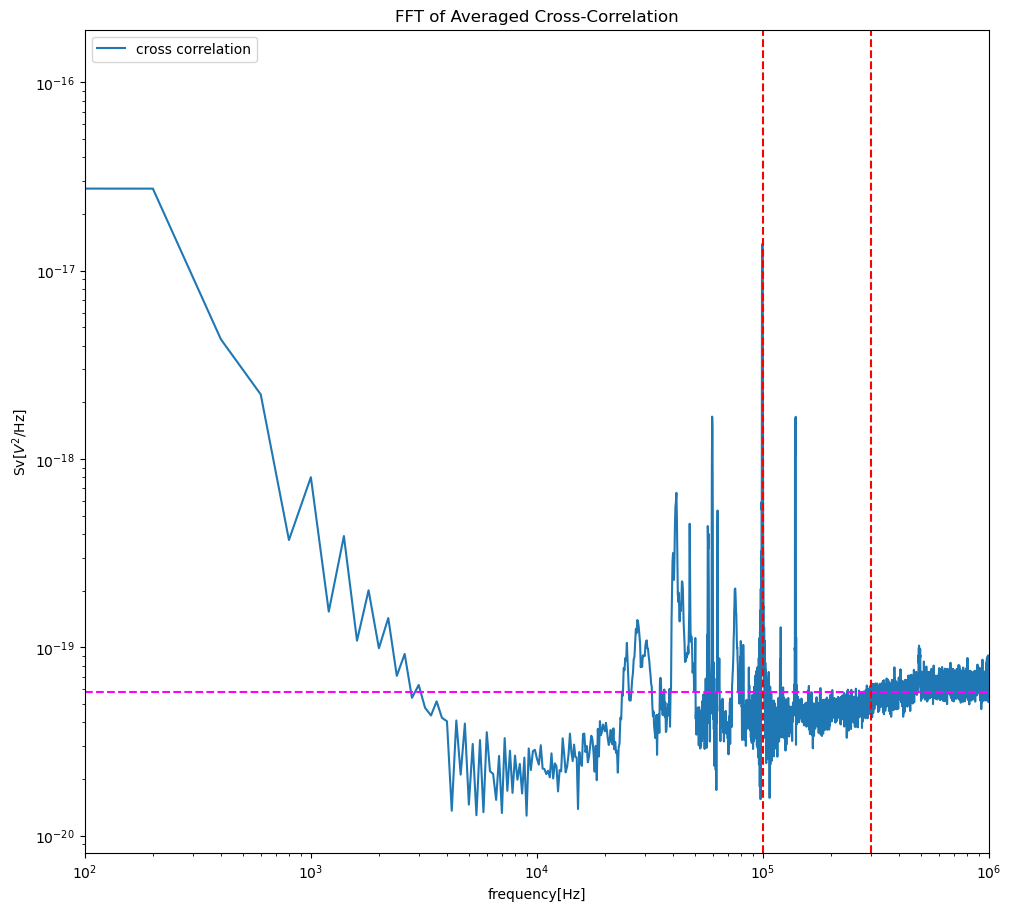

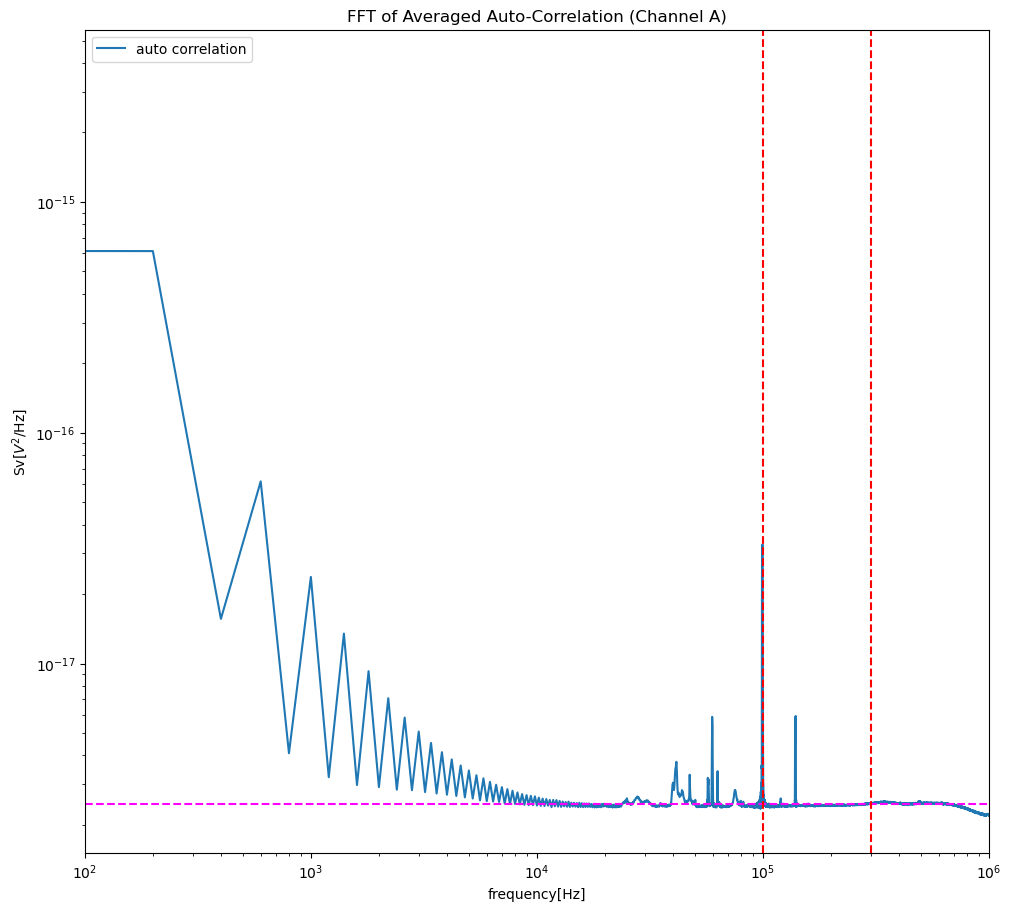

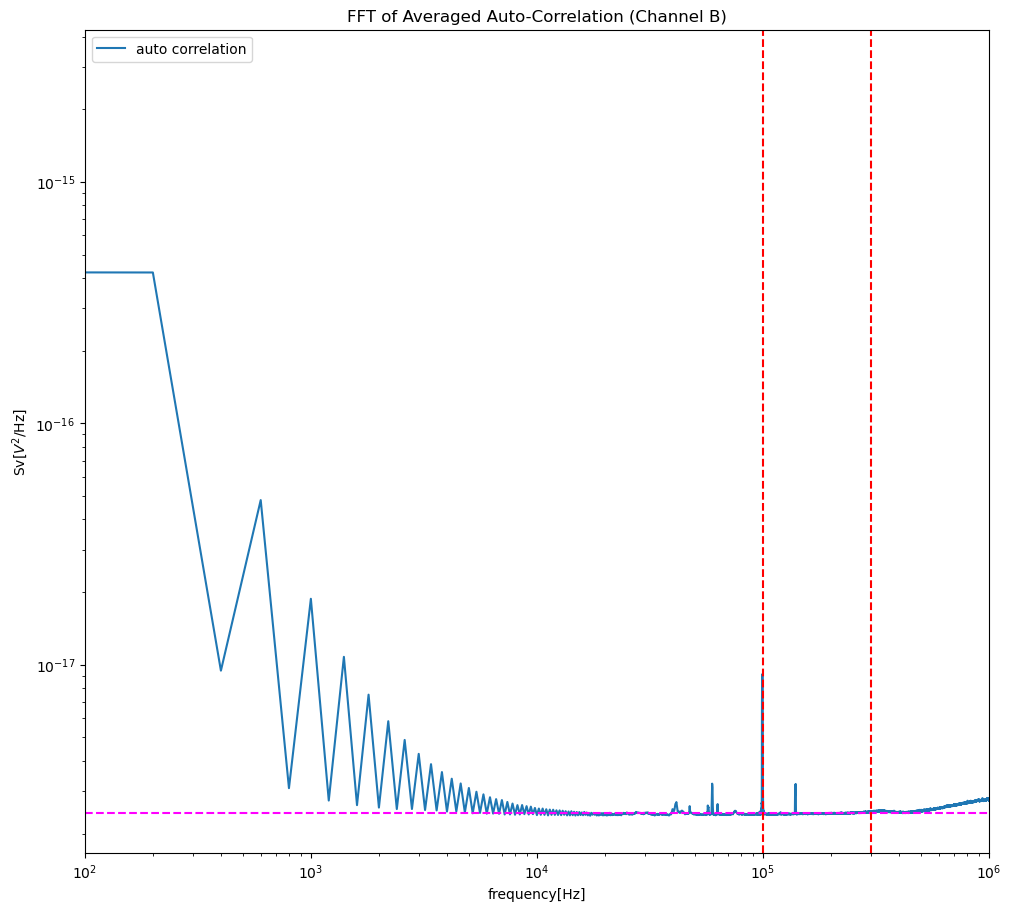

In [ ]:
# Helper function for cross correlation
def xcorr_avg_mV(a_mv, b_mv, n_bins):
    A = np.asarray(a_mv, dtype=float)
    B = np.asarray(b_mv, dtype=float)
    A_splits = np.array_split(A, n_bins)
    B_splits = np.array_split(B, n_bins)
    acc = None
    for Ab, Bb in zip(A_splits, B_splits):
        c = correlate(Ab, Bb, mode="same", method="fft") / (len(Bb) * 1e6)
        acc = c if acc is None else (acc + c)
    return acc / n_bins

# Helper function for auto correlation
def autocorr_avg_mV(x_mv, n_bins):
    X = np.asarray(x_mv, dtype=float)
    X_splits = np.array_split(X, n_bins)
    acc = None
    for Xb in X_splits:
        c = correlate(Xb, Xb, mode="same", method="fft") / (len(Xb) * 1e6)
        acc = c if acc is None else (acc + c)
    return acc / n_bins

# acquire_one_batch helper function. To be theoretically looped for more averaging

def acquire_one_batch(numAcquisitions, n_segments, n_Bin):

    average_cross_corr = None
    cmaxSamples_Time = ctypes.c_int32(np.int32(maxSamples/n_Bin))

    for i in range(numAcquisitions):
        #sleep(1)
        nMaxSamples = ctypes.c_int32(0)
        status["setMemorySegments"] = ps.ps4000MemorySegments(chandle, n_segments, ctypes.byref(nMaxSamples))
        assert_pico_ok(status["setMemorySegments"])

        # Set number of captures
        # handle = chandle
        # nCaptures = 10
        status["SetNoOfCaptures"] = ps.ps4000SetNoOfCaptures(chandle, n_segments)
        assert_pico_ok(status["SetNoOfCaptures"])
        
        # set up buffers for A and B - n_segments each
        buffersA = [(ctypes.c_int16 * maxSamples)() for _ in range(n_segments)]
        buffersB = [(ctypes.c_int16 * maxSamples)() for _ in range(n_segments)]

        # set data buffers
        # handle = chandle
        # channel = PS4000A_CHANNEL_A = 0
        # buffer = bufferAX (where X = segmentIndex)
        # bufferLength = maxSamples
        # segmentIndex = X
        # mode = PS4000A_RATIO_MODE_NONE = 0

        for seg_idx in range(n_segments):
            status[f"setDataBufferA{seg_idx}"] = ps.ps4000SetDataBuffer(chandle, 0, ctypes.byref(buffersA[seg_idx]), maxSamples)

        for seg_idx in range(n_segments):
            status[f"setDataBufferB{seg_idx}"] = ps.ps4000SetDataBuffer(chandle, 0, ctypes.byref(buffersB[seg_idx]), maxSamples)


        # run block capture
        # handle = chandle
        # number of pre-trigger samples = preTriggerSamples
        # number of post-trigger samples = PostTriggerSamples
        # timebase = 3 = 80 ns = timebase (see Programmer's guide for mre information on timebases)
        # time indisposed ms = None (not needed in the example)
        # segment index = 0
        # lpReady = None (using ps4000aIsReady rather than ps4000aBlockReady)
        #pParameter = None
        status["runBlock"] = ps.ps4000RunBlock(chandle, preTriggerSamples, postTriggerSamples, timebase, oversample, None, 0, None, False)
        assert_pico_ok(status["runBlock"])

        # check for end of capture
        ready = ctypes.c_int16(0)
        check = ctypes.c_int16(0)
        while ready.value == check.value:
            status["isReady"] = ps.ps4000IsReady(chandle, ctypes.byref(ready))

        # Creates a overlow location for data
        overflow = (ctypes.c_int16 * n_segments)()
        # Creates converted types maxsamples
        cmaxSamples=ctypes.c_int32(np.int32(maxSamples))
        # cmaxSamples_Time = ctypes.c_int32(np.int32(maxSamples/n_Bin)) ### adjusting time axis for n_Bin bins ## Removed this and defined it at the top to avoid redefining it each iteraiton

        for seg_idx in range(n_segments):
            status["setDataBufferBulk"] = ps.ps4000SetDataBufferBulk(chandle, 0, buffersA[seg_idx], maxSamples, seg_idx)
        
        for seg_idx in range(n_segments):
            status["setDataBufferBulk"] = ps.ps4000SetDataBufferBulk(chandle, 1, buffersB[seg_idx], maxSamples, seg_idx)


        # collect data 
        # handle = chandle
        # noOfSamples = cmaxSamples
        # fromSegmentIndex = 0
        # toSegmentIndex = 9
        # downSampleRatio = 1
        # downSampleRatioMode = PS4000A_RATIO_MODE_NONE
        status["getValuesBulk"] = ps.ps4000GetValuesBulk(chandle, ctypes.byref(cmaxSamples), 0, n_segments - 1, ctypes.byref(overflow))
        assert_pico_ok(status["getValuesBulk"])

        # find maximum ADC count value
        # handle = chandle
        # pointer to value = ctypes.byref(maxADC)
        maxADC = ctypes.c_int16(32767)

        # convert from adc to mV
        adc2mVChA = [adc2mV(buffersA[i], chARange, maxADC) for i in range(n_segments)]
        adc2mVChB = [adc2mV(buffersB[i], chARange, maxADC) for i in range(n_segments)]

        #print(len(adc2mVChA0))

        # Perform cross-correlation on this iteration (factor of 1e6 is for mV to V conversion for two channels)

        A_mv = [np.array(ch) for ch in adc2mVChA]
        B_mv = [np.array(ch) for ch in adc2mVChB]

        seg_corrs = [xcorr_avg_mV(A_mv[k], B_mv[k], n_Bin) for k in range(n_segments)]
        cross_corr_avg = np.mean(np.stack(seg_corrs, axis=0), axis=0)

        # Autocorrelation
        seg_auto_A = [autocorr_avg_mV(A_mv[k], n_Bin) for k in range(n_segments)]
        seg_auto_B = [autocorr_avg_mV(B_mv[k], n_Bin) for k in range(n_segments)]
        auto_corr_avg_A = np.mean(np.stack(seg_auto_A, axis=0), axis=0)
        auto_corr_avg_B = np.mean(np.stack(seg_auto_B, axis=0), axis=0)
        

        # If this is the first acquisition, initialize the average list
        if i == 0:
            average_cross_corr = cross_corr_avg
            average_auto_A = auto_corr_avg_A
            average_auto_B = auto_corr_avg_B
        else:
            # Update the average cross-correlation
            average_cross_corr = [(x + y) for x, y in zip(average_cross_corr, cross_corr_avg)]
            average_auto_A = [(x + y) for x, y in zip(average_auto_A, auto_corr_avg_A)]
            average_auto_B = [(x + y) for x, y in zip(average_auto_B, auto_corr_avg_B)]
            
        print("Acquisition number:", i + 1)
        #print(np.(average_cross_corr))

    # Final average cross-correlation is now in average_cross_corr
    return average_cross_corr, average_auto_A, average_auto_B, cmaxSamples_Time


# Collect average correlation from multiple batches
all_xcorrs = []
all_A_autocorrs = []
all_B_autocorrs = []
for run in range(num_runs):
    avg_corr, avg_auto_A, avg_auto_B, cmaxSamples_Time = acquire_one_batch(numAcquisitions, n_segments, n_Bin) # Acquires num_runs batches
    all_xcorrs.append(avg_corr)
    all_A_autocorrs.append(avg_auto_A)
    all_B_autocorrs.append(avg_auto_B)
    print(f"Completed run {run + 1}/{num_runs}")


final_average_xcorr = np.sum(np.stack(all_xcorrs, axis=0), axis=0)
final_average_A_autocorr = np.sum(np.stack(all_A_autocorrs, axis=0), axis=0)
final_average_B_autocorr = np.sum(np.stack(all_B_autocorrs, axis=0), axis=0)

# Create time data
time = np.linspace(0, ((cmaxSamples_Time.value) - 1) * timeIntervalns.value/1e9, cmaxSamples_Time.value) # Changes time to seconds instead of nanoseconds
T = (time.max()-time.min()) # seconds
N = np.size(time)
fs = int(N/T) # Hz
dt = 1/fs
fwelch = fftfreq(N,dt)
fwelch = fwelch[:fwelch.size//2]



############ Calculate the FFT of the averaged correlations ############
def one_sided_psd_from_corr(corr, fs):
    Sv_corr = np.absolute(fftshift(fft(corr)))
    Sv_corr=2*Sv_corr[Sv_corr.size//2:]
    Sv_corr=Sv_corr/fs
    Sv_corr=Sv_corr/(g * g * numAcquisitions * num_runs) 
    return Sv_corr

Sv_xcorr = one_sided_psd_from_corr(final_average_xcorr, fs)
Sv_autoA = one_sided_psd_from_corr(final_average_A_autocorr, fs)
Sv_autoB = one_sided_psd_from_corr(final_average_B_autocorr, fs)

############# Print the PSDs between two frequency set points ##########
f_lo = 100_000 # Hz
f_hi = 300_000 # Hz
print(f"Cross PSD  = {np.mean(Sv_xcorr[np.where((fwelch>f_lo) & (fwelch<f_hi))])} between {f_lo} and {f_hi} Hz")
print(f"AutoA PSD  = {np.mean(Sv_autoA[np.where((fwelch>f_lo) & (fwelch<f_hi))])} between {f_lo} and {f_hi} Hz")
print(f"AutoB PSD  = {np.mean(Sv_autoB[np.where((fwelch>f_lo) & (fwelch<f_hi))])} between {f_lo} and {f_hi} Hz")

########## Plotting the PSDs vs frequency ######
# Helper function
def plot_psd(Sv_corr, title, label):
    fig, ax = plt.subplots(figsize=(10,9), constrained_layout=True)
    ax.plot(fwelch, Sv_corr, alpha=1, label = label)
    ax.axhline(np.mean(Sv_corr[np.where((fwelch>f_lo) & (fwelch<f_hi))]), color='magenta', linestyle='--')
    ax.set_xlabel("frequency[Hz]")
    ax.set_ylabel("Sv[$V^2$/Hz]")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e2,1e6)
    # ax.set_ylim(1e-21,1e-15)
    ax.axvline(f_hi, color='r', linestyle='--')
    ax.axvline(f_lo, color='r', linestyle='--')
    plt.title(title)
    ax.legend()
    plt.show()

# Cross PSD
plot_psd(Sv_xcorr, "FFT of Averaged Cross-Correlation", "cross correlation")

# Auto PSD (Channel A)
plot_psd(Sv_autoA, "FFT of Averaged Auto-Correlation (Channel A)", "auto correlation")

# Auto PSD (Channel B)
plot_psd(Sv_autoB, "FFT of Averaged Auto-Correlation (Channel B)", "auto correlation")


# Stop the scope
# handle = chandle
status["stop"] = ps.ps4000Stop(chandle)
assert_pico_ok(status["stop"])


#Close unit Disconnect the scope
#handle = chandle
status["close"] = ps.ps4000CloseUnit(chandle)
assert_pico_ok(status["close"])


In [ ]:
############ Saving the PSD data into files ###############
np.savetxt('output/shuntbox_12and4_gain_5e4_1e4avg_2Ms_10Ksa_20250909_10avg_12and4shorted.hdf5', [(x,y) for x,y in zip(fwelch,Sv_xcorr)], delimiter=',')
np.savetxt('output/shuntbox_12and4_gain_5e4_1e4avg_2Ms_10Ksa_20250909_10avg_12and4shorted_ChannelA.hdf5', [(x,y) for x,y in zip(fwelch,Sv_autoA)], delimiter=',')
np.savetxt('output/shuntbox_12and4_gain_5e4_1e4avg_2Ms_10Ksa_20250909_10avg_12and4shorted_ChannelB.hdf5', [(x,y) for x,y in zip(fwelch,Sv_autoB)], delimiter=',')


# Close the Picoscope

In [8]:
# Close unit Disconnect the scope
# handle = chandle
status["close"] = ps.ps4000CloseUnit(chandle)
assert_pico_ok(status["close"])


PicoSDKCtypesError: PicoSDK returned 'PICO_INVALID_HANDLE'